In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
SEQ = Path.home() / \
"HDD/EventDatasets/EVIMO2_official/left_camera/imo/train/scene13_dyn_test_02_000000"

mask = np.load(SEQ / "dataset_mask.npz")

print(type(mask))

<class 'numpy.lib.npyio.NpzFile'>


In [3]:
print("="*80)
print("Keys")
print("="*80)

for key in mask.files:
    print(key)

print()
print("Total masks:", len(mask.files))

Keys
mask_0000000453
mask_0000000752
mask_0000000471
mask_0000000106
mask_0000000196
mask_0000000084
mask_0000000572
mask_0000000079
mask_0000000547
mask_0000000380
mask_0000000310
mask_0000000691
mask_0000000430
mask_0000000476
mask_0000000690
mask_0000000756
mask_0000000432
mask_0000000382
mask_0000000258
mask_0000000502
mask_0000000680
mask_0000000421
mask_0000000413
mask_0000000315
mask_0000000244
mask_0000000254
mask_0000000763
mask_0000000154
mask_0000000288
mask_0000000070
mask_0000000270
mask_0000000399
mask_0000000374
mask_0000000422
mask_0000000460
mask_0000000491
mask_0000000440
mask_0000000597
mask_0000000539
mask_0000000667
mask_0000000428
mask_0000000392
mask_0000000295
mask_0000000567
mask_0000000542
mask_0000000093
mask_0000000516
mask_0000000439
mask_0000000208
mask_0000000321
mask_0000000520
mask_0000000201
mask_0000000492
mask_0000000603
mask_0000000688
mask_0000000748
mask_0000000230
mask_0000000115
mask_0000000354
mask_0000000754
mask_0000000402
mask_0000000737
mas

In [4]:
import random

for key in random.sample(mask.files, 5):

    m = mask[key]

    print("="*100)
    print(key)
    print("="*100)

    print("Shape :", m.shape)
    print("Dtype :", m.dtype)

    print("Min :", m.min())
    print("Max :", m.max())

    print("Unique values (first 20)")

    vals = np.unique(m)

    print(vals[:20])

    print("Number of unique IDs :", len(vals))

    print()

mask_0000000745
Shape : (480, 640)
Dtype : uint16
Min : 0
Max : 22000
Unique values (first 20)
[    0  5000 14000 22000]
Number of unique IDs : 4

mask_0000000088
Shape : (480, 640)
Dtype : uint16
Min : 0
Max : 24000
Unique values (first 20)
[    0  5000  6000 11000 14000 15000 22000 23000 24000]
Number of unique IDs : 9

mask_0000000661
Shape : (480, 640)
Dtype : uint16
Min : 0
Max : 0
Unique values (first 20)
[0]
Number of unique IDs : 1

mask_0000000111
Shape : (480, 640)
Dtype : uint16
Min : 0
Max : 24000
Unique values (first 20)
[    0  5000  6000 11000 14000 15000 22000 23000 24000]
Number of unique IDs : 9

mask_0000000453
Shape : (480, 640)
Dtype : uint16
Min : 0
Max : 24000
Unique values (first 20)
[    0  6000 11000 14000 22000 24000]
Number of unique IDs : 6



In [5]:
print("Number of masks:", len(mask.files))

indices = sorted(int(k.split("_")[-1]) for k in mask.files)

print()

print("First 20")
print(indices[:20])

print()

print("Last 20")
print(indices[-20:])

print()

print("Min index:", min(indices))
print("Max index:", max(indices))

print("Missing:", (max(indices)+1)-len(indices))

Number of masks: 750

First 20
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

Last 20
[762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 781]

Min index: 0
Max index: 781
Missing: 32


In [6]:
shapes = set()
dtypes = set()

for key in mask.files:

    img = mask[key]

    shapes.add(img.shape)
    dtypes.add(img.dtype)

print("Shapes")
print(shapes)

print()

print("Dtypes")
print(dtypes)

Shapes
{(480, 640)}

Dtypes
{dtype('uint16')}


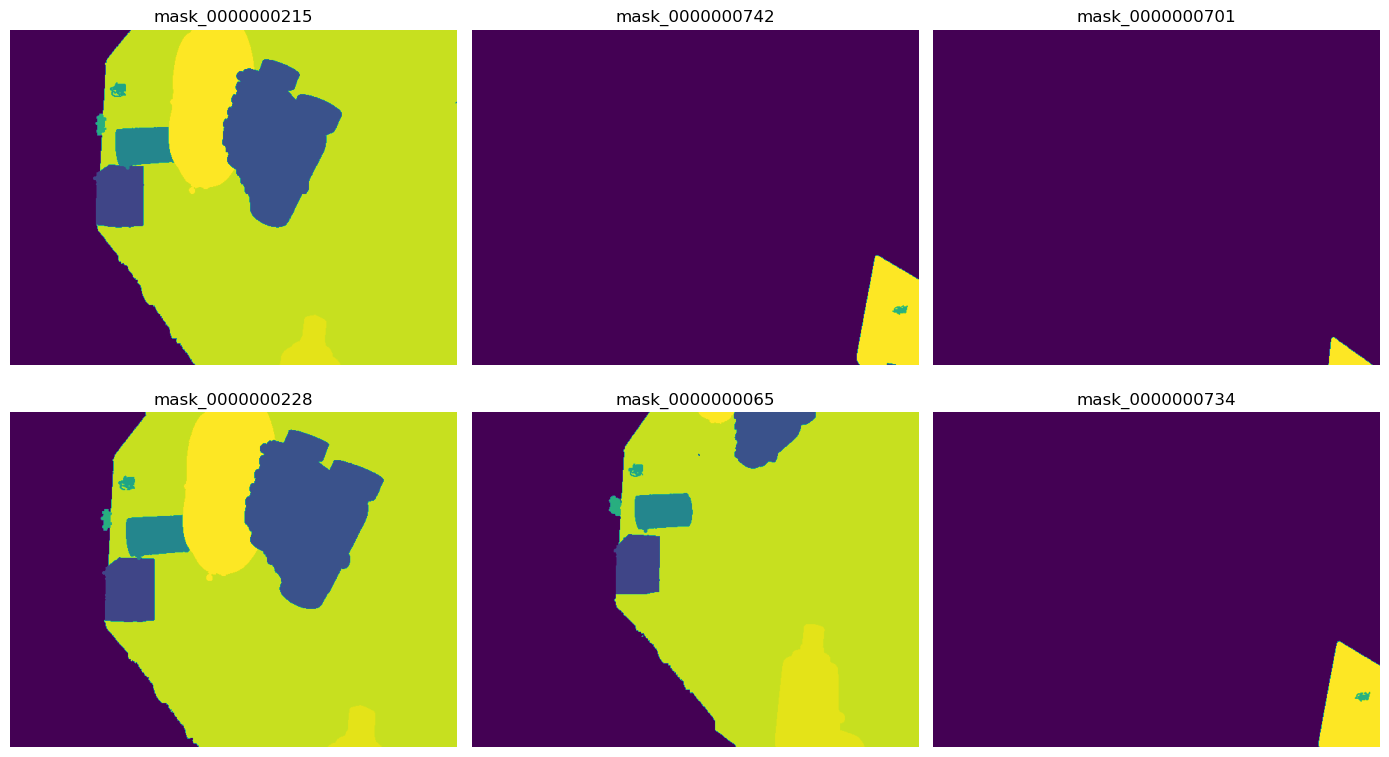

In [7]:
fig, axes = plt.subplots(2,3, figsize=(14,8))

for ax, key in zip(axes.ravel(), random.sample(mask.files,6)):

    img = mask[key]

    ax.imshow(img)

    ax.set_title(key)

    ax.axis("off")

plt.tight_layout()

In [8]:
for key in random.sample(mask.files,5):

    img = mask[key]

    ids, counts = np.unique(img, return_counts=True)

    print("="*80)
    print(key)

    print("Object IDs:")
    print(ids)

    print()

    print("Pixel count")

    for i, c in zip(ids, counts):
        print(i, c)

    print()

mask_0000000381
Object IDs:
[    0  5000  6000 11000 14000 15000 22000 23000 24000]

Pixel count
0 115806
5000 6737
6000 12152
11000 4890
14000 299
15000 318
22000 137701
23000 14900
24000 14397

mask_0000000313
Object IDs:
[    0  5000  6000 11000 14000 15000 22000 24000]

Pixel count
0 139042
5000 7236
6000 11471
11000 5367
14000 301
15000 291
22000 122226
24000 21266

mask_0000000078
Object IDs:
[    0  5000  6000 11000 14000 15000 22000 23000 24000]

Pixel count
0 120557
5000 5214
6000 8469
11000 3869
14000 278
15000 286
22000 151739
23000 14635
24000 2153

mask_0000000217
Object IDs:
[    0  5000  6000 11000 14000 15000 22000 23000 24000]

Pixel count
0 74110
5000 5875
6000 25858
11000 4103
14000 332
15000 331
22000 173847
23000 3139
24000 19605

mask_0000000141
Object IDs:
[    0  5000  6000 11000 14000 15000 22000 23000 24000]

Pixel count
0 123097
5000 5343
6000 12860
11000 3673
14000 278
15000 279
22000 127824
23000 23501
24000 10345



In [10]:
for key in random.sample(mask.files,5):

    img = mask[key]

    ids, counts = np.unique(img, return_counts=True)

    largest = ids[np.argmax(counts)]

    print("="*80)
    print(key)

    print("Largest ID:", largest)

    print("Pixels:", counts.max())

mask_0000000745
Largest ID: 0
Pixels: 296020
mask_0000000687
Largest ID: 0
Pixels: 307040
mask_0000000758
Largest ID: 0
Pixels: 296598
mask_0000000115
Largest ID: 22000
Pixels: 128049
mask_0000000243
Largest ID: 22000
Pixels: 133822
